In [1]:
using Lux, Reactant, Enzyme, NNlib
using Optimisers, Random, Statistics, Images
using LinearAlgebra, Images, JLD2, ComponentArrays
using Dates, Plots, UnicodePlots

In [22]:
const xdev = reactant_device(; force=true)
const cdev = cpu_device()
dev = cdev
rng = Xoshiro()

Xoshiro(0xe4d440fc7b30f03f, 0xd940ae4e940026aa, 0xf719e14e02b1836e, 0x0223bfcc9b7336d3, 0x5311f10684cf7528)

In [23]:
    @load "ps_latestvn.jld2" ps_cpu 
    @load "st_latestvn.jld2" st_cpu
    ps = ps_cpu |> dev
    st = st_cpu |> dev

(layer_1 = (conv = NamedTuple(),), layer_2 = (layer_1 = NamedTuple(), layer_2 = (layer_1 = NamedTuple(), layer_2 = NamedTuple(), layer_3 = NamedTuple()), layer_3 = NamedTuple(), layer_4 = NamedTuple()), layer_3 = NamedTuple(), layer_4 = NamedTuple(), layer_5 = NamedTuple())

In [24]:
include("model.jl")
include("helperfuncs.jl")

forward (generic function with 1 method)

In [29]:
function wrap_model(st, ps, model, emb_dim)
    return (x,t) -> begin
        x_dim, y_dim = size(x)
        out = ones(Float32, x_dim, y_dim, 2+emb_dim)
        emb = reshape(sinusoidal_embedding(Float32(t), emb_dim), (1,1,emb_dim))
        out[:, :, 1] = x
        out[:, :, 3:end] .= emb
        return reshape(model(out |> dev, ps,st)[1],(x_dim,y_dim))
    end
end

wrap_model (generic function with 1 method)

In [38]:
f = wrap_model(st,ps,model, emb_dim)

#wrap_model##8 (generic function with 1 method)

In [39]:
x = randn(Float32, 64,64)

64×64 Matrix{Float32}:
  0.523855   -0.288534    0.71867     …   0.308074  -0.114995  -1.19764
  0.960232   -0.143672   -0.135443       -0.426751   0.246797  -0.393557
  0.980945   -0.310227    0.00528993      2.71978   -0.899727  -1.12088
 -0.103168   -0.457116    0.83527         0.815591  -0.779457  -2.38704
  0.919893    0.772402   -0.967022        0.123186   0.820434   1.25868
  1.1272      0.354243   -0.617811    …   0.737566   1.01262    2.04484
  0.56048    -0.671835    1.10763        -1.13311   -1.53683   -0.208175
  0.645984    2.42597    -1.50758        -1.00513    1.43499   -0.64191
 -1.74464     1.12878     0.55            0.263365   1.18205    1.35851
 -0.0197066   0.0686164   0.485619       -0.910969  -1.19405   -0.289122
  ⋮                                   ⋱                        
  0.714416   -0.805371    1.24178     …   0.169005   0.844087  -1.79829
  0.0678015  -0.582084   -1.4882         -0.229697   2.23864    0.485383
 -0.730454    1.51037     0.378012       -1.5

In [40]:
f(x,1)

64×64 Matrix{Float32}:
  0.514999   -0.290359    0.716962    …   0.304959  -0.118495  -1.19799
  0.958249   -0.141066   -0.136039       -0.450779   0.236888  -0.407865
  0.982247   -0.307928    0.00686298      2.72499   -0.902426  -1.11043
 -0.104963   -0.452597    0.834049        0.821686  -0.768544  -2.36863
  0.922831    0.779917   -0.969116        0.115353   0.81761    1.26493
  1.12538     0.351184   -0.614237    …   0.729075   1.01653    2.05375
  0.563616   -0.666866    1.10116        -1.12974   -1.52841   -0.219568
  0.649869    2.4149     -1.49943        -1.0004     1.43558   -0.634085
 -1.72868     1.13008     0.547915        0.257256   1.1851     1.35859
 -0.0200503   0.0662598   0.480343       -0.907021  -1.18553   -0.280234
  ⋮                                   ⋱                        
  0.715402   -0.794878    1.23828     …   0.166405   0.844849  -1.79243
  0.0719192  -0.5728     -1.48334        -0.229408   2.23813    0.477714
 -0.737811    1.5041      0.372803       -1.

In [34]:
sinusoidal_embedding(1f0, emb_dim)

32-element Vector{Float32}:
 0.84147096
 0.51513875
 0.2886959
 0.15782666
 0.08566448
 0.04639923
 0.02511623
 0.0135931475
 0.0073563578
 0.0039810613
 ⋮
 0.9999076
 0.99997294
 0.9999921
 0.9999977
 0.99999934
 0.9999998
 0.99999994
 1.0
 1.0

In [46]:
function reverse_sampler_step!(xt,t, model, Δt, β, ᾱ, args...)
    β_t = β(t); ᾱ_t = ᾱ(t)    
    ε_pred = model(xt, t,args...)
    drift = (0.5 * β_t .* xt) .- ((β_t / sqrt(1.0 - ᾱ_t)) .* ε_pred)
    z = randn(size(xt))
    diffusion = sqrt(β_t * Δt) .* z
    xt .+= (drift .* Δt) .+ diffusion
    return xt, t-Δt
end

reverse_sampler_step! (generic function with 1 method)

In [69]:
t = 1
xt = randn(Float32,128,128)
Δt = 0.01
step = 1
while t>0 && step < 110
    step +=1
    xt,t = reverse_sampler_step!(xt,t,f,Δt, β, ᾱ)
    print("$step : $t ")
end

2 : 0.99 3 : 0.98 4 : 0.97 5 : 0.96 6 : 0.95 7 : 0.94 8 : 0.9299999999999999 9 : 0.9199999999999999 10 : 0.9099999999999999 11 : 0.8999999999999999 12 : 0.8899999999999999 13 : 0.8799999999999999 14 : 0.8699999999999999 15 : 0.8599999999999999 16 : 0.8499999999999999 17 : 0.8399999999999999 18 : 0.8299999999999998 19 : 0.8199999999999998 20 : 0.8099999999999998 21 : 0.7999999999999998 22 : 0.7899999999999998 23 : 0.7799999999999998 24 : 0.7699999999999998 25 : 0.7599999999999998 26 : 0.7499999999999998 27 : 0.7399999999999998 28 : 0.7299999999999998 29 : 0.7199999999999998 30 : 0.7099999999999997 31 : 0.6999999999999997 32 : 0.6899999999999997 33 : 0.6799999999999997 34 : 0.6699999999999997 35 : 0.6599999999999997 36 : 0.6499999999999997 37 : 0.6399999999999997 38 : 0.6299999999999997 39 : 0.6199999999999997 40 : 0.6099999999999997 41 : 0.5999999999999996 42 : 0.5899999999999996 43 : 0.5799999999999996 44 : 0.5699999999999996 45 : 0.5599999999999996 46 : 0.5499999999999996 47 : 0.53999

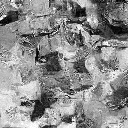

In [70]:
img4 = Gray.(clamp.(denormalize_image(xt),0.0,1.0))

In [71]:
save("img04.png", img4)

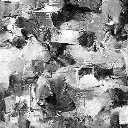

In [72]:
img1

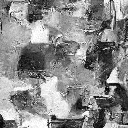

In [73]:
img2